In [ ]:
# =========================
# 1) Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import soundfile as sf
import librosa
import scipy.signal as sps

# =========================================
# Paths
# =========================================
input_folder = "/content/drive/MyDrive/MusicGen_Project/Data/MusicGen_Output/"
output_folder = "/content/drive/MyDrive/MusicGen_Project/Data/Degraded/AudioSR/"

os.makedirs(output_folder, exist_ok=True)

# =========================================
# Parameters
# =========================================
target_sr = 48000
cutoff_hz = 8000      # tried also 4000 and 12000
filter_order = 8
rp_db = 0.05

# =========================================
# Functions
# =========================================
def peak_normalize(x, peak=0.98):
    m = np.max(np.abs(x))
    if m < 1e-12:
        return x
    return x * (peak / m)

def remove_dc(x):
    return x - np.mean(x)

def cheby_lowpass(y, sr, cutoff_hz, order=8, rp=0.05):
    nyq = sr / 2.0
    wn = cutoff_hz / nyq
    b, a = sps.cheby1(order, rp, wn, btype="low")
    return sps.filtfilt(b, a, y).astype(np.float32)

# =========================================
# Loop over all files
# =========================================
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        input_path = os.path.join(input_folder, file)
        output_path = os.path.join(output_folder, file)

        print("Processing:", file)

        # Load
        y, sr = sf.read(input_path)
        if y.ndim == 2:
            y = np.mean(y, axis=1)

        y = y.astype(np.float32)

        # Clean a bit
        y = remove_dc(y)
        y = peak_normalize(y)

        # Resample to 48k
        y_48k = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

        # Low-pass filter
        y_lp = cheby_lowpass(y_48k, target_sr, cutoff_hz, filter_order, rp_db)

        # Normalize again
        y_lp = peak_normalize(y_lp)

        # Save
        sf.write(output_path, y_lp, target_sr)

print("Done preprocessing for AudioSR.")

Processing: piano_01.wav
Processing: piano_02.wav
Processing: piano_03.wav
Processing: piano_04.wav
Processing: piano_05.wav
Processing: guitar_01.wav
Processing: guitar_02.wav
Processing: guitar_03.wav
Processing: guitar_04.wav
Processing: guitar_05.wav
Processing: drums_01.wav
Processing: drums_02.wav
Processing: drums_03.wav
Processing: drums_04.wav
Processing: drums_05.wav
Processing: ambient_01.wav
Processing: ambient_02.wav
Processing: ambient_03.wav
Processing: ambient_04.wav
Processing: ambient_05.wav
Processing: electronic_01.wav
Processing: electronic_02.wav
Processing: electronic_03.wav
Processing: electronic_04.wav
Processing: electronic_05.wav
Processing: orchestral_01.wav
Processing: orchestral_02.wav
Processing: orchestral_03.wav
Processing: orchestral_04.wav
Processing: orchestral_05.wav
Done preprocessing for AudioSR.


In [ ]:
# =========================
# Listen BEFORE vs AFTER for all files
# =========================
import os
import glob
from IPython.display import Audio, display

apollo_input_dir = input_folder
apollo_output_dir = output_folder

input_files = sorted(glob.glob(os.path.join(apollo_input_dir, "*.wav")))

print("Found files:", len(input_files))

for in_file in input_files:
    base = os.path.basename(in_file)
    out_file = os.path.join(
        apollo_output_dir,
        base.replace("_apollo_input", "_apollo_output")
    )

    print("\n==============================")
    print("File:", base)
    print("==============================")

    if os.path.exists(out_file):
        print("Apollo INPUT (degraded)")
        display(Audio(in_file))

        print("Apollo OUTPUT (restored)")
        display(Audio(out_file))
    else:
        print("Output file not found for:", base)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

orig_path = input_musicgen_wav
rest_path = output_wav

y1, sr1 = librosa.load(orig_path, sr=None)
y2, sr2 = librosa.load(rest_path, sr=None)

print("Original sr:", sr1, "length:", len(y1)/sr1, "sec")
print("Restored sr:", sr2, "length:", len(y2)/sr2, "sec")

Original sr: 32000 length: 5.06 sec
Restored sr: 32000 length: 5.06 sec


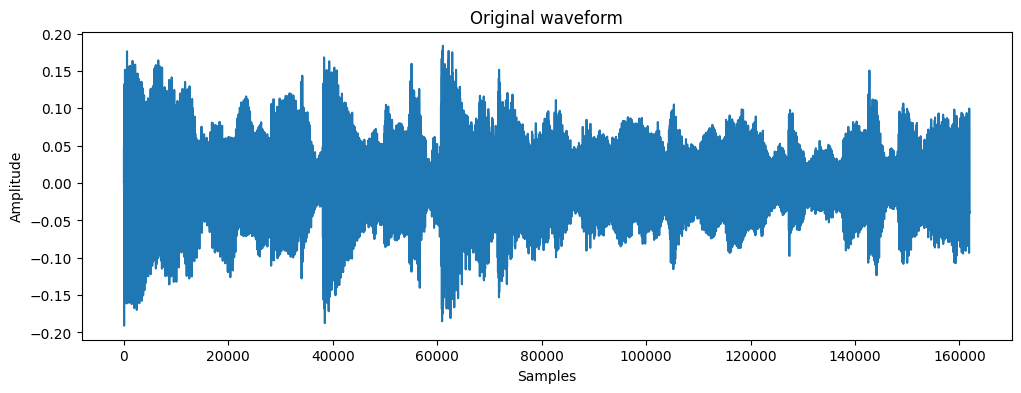

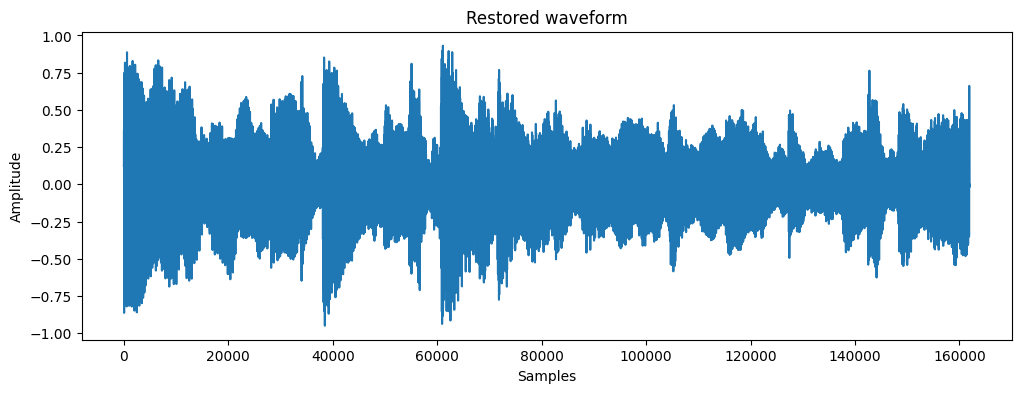

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(y1)
plt.title("Original waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(y2)
plt.title("Restored waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
y1, sr1 = librosa.load(orig_path, sr=None)
y2, sr2 = librosa.load(rest_path, sr=None)

min_len = min(len(y1), len(y2))
y1 = y1[:min_len]
y2 = y2[:min_len]

print("Same sample rate:", sr1 == sr2)
print("Same length:", len(y1) == len(y2))
print("Max abs difference:", np.max(np.abs(y1 - y2)))
print("Mean abs difference:", np.mean(np.abs(y1 - y2)))
print("All close:", np.allclose(y1, y2, atol=1e-6))

Same sample rate: True
Same length: True
Max abs difference: 0.76257324
Mean abs difference: 0.1405564
All close: False
